In [2]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

Matplotlib is building the font cache; this may take a moment.


In [3]:
DATA_ROOT = Path("demo_output")
CSV_ROOT = DATA_ROOT / "csv"

if not CSV_ROOT.exists():
    raise FileNotFoundError(f"Expected folder not found: {CSV_ROOT.resolve()}")


sns.set_theme(style="whitegrid", context="notebook")


DATE_COLUMNS: dict[str, list[str]] = {
    "customers": ["date_of_birth", "registration_date"],
    "loanapplications": ["application_date", "decision_date"],
    "loanaccounts": ["origination_date", "maturity_date", "next_payment_due_date"],
    "paymenthistory": ["payment_date"],
}

ID_COLUMNS: dict[str, list[str]] = {
    "customers": ["customer_id"],
    "loanapplications": ["application_id", "customer_id"],
    "loanaccounts": ["loan_account_id", "application_id", "customer_id"],
    "paymenthistory": ["payment_id", "loan_account_id"],
}


def load_table(name: str) -> pd.DataFrame:
    df = pd.read_csv(CSV_ROOT / f"{name}.csv")

    for col in DATE_COLUMNS.get(name, []):
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")

    for col in ID_COLUMNS.get(name, []):
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")

    return df

# 1) Load demo_output tables

In [4]:
customers = load_table("customers")
loanapplications = load_table("loanapplications")
loanaccounts = load_table("loanaccounts")
paymenthistory = load_table("paymenthistory")

tables: dict[str, pd.DataFrame] = {
    "customers": customers,
    "loanapplications": loanapplications,
    "loanaccounts": loanaccounts,
    "paymenthistory": paymenthistory,
}

overview = pd.DataFrame(
    [
        {
            "table": name,
            "rows": len(df),
            "columns": len(df.columns),
        }
        for name, df in tables.items()
    ]
).sort_values("rows", ascending=False)

print("Table overview")
display(overview)

Table overview


,table,rows,columns
3,paymenthistory,118,9
0,customers,74,11
1,loanapplications,74,11
2,loanaccounts,74,13


# 2) Quick table previews

In [5]:
for name, df in tables.items():
    print(f"\n{name} (top 5 rows)")
    display(df.head())


customers (top 5 rows)


,customer_id,first_name,last_name,date_of_birth,email,phone_number,address_json,credit_score,income_annual,employment_status,registration_date
0,1,Danielle,Johnson,1958-12-04,NaN,+1-219-560-0133,"{""source"": ""synthetic_generator"", ""tags"": [""se...",719.0,3006.39,Active,1973-12-04 01:57:04
1,2,Jacqueline,Barnes,1970-10-09,lisa02@example.net,(254)923-5116x15594,"{""source"": ""synthetic_generator"", ""tags"": [""no...",665.0,2257.28,Pending,2025-09-11 06:46:23
2,3,Teresa,Gray,NaT,barbara10@example.net,441.731.6475,"{""source"": ""synthetic_generator"", ""tags"": [""he...",749.0,NaN,Active,2023-10-29 16:10:13
3,4,Elizabeth,Miles,1986-09-15,lynchgeorge@example.net,527.264.8350,"{""source"": ""synthetic_generator"", ""tags"": [""su...",580.0,7195.19,Active,2023-01-20 02:50:43
4,5,Richard,Jones,2002-04-26,jason76@example.net,724.523.8849x696,"{""source"": ""synthetic_generator"", ""tags"": [""ce...",NaN,2531.54,Active,2009-07-20 10:20:11



loanapplications (top 5 rows)


,application_id,customer_id,application_date,loan_amount_requested,loan_term_months_requested,loan_purpose,application_status,risk_assessment_score,decision_date,rejection_reason,application_data_json
0,1,31,1996-09-13,2623.83,11,loan_purpose_c,Pending,778.0,2009-08-29 17:09:37,Agreement us stuff practice social. Although t...,"{""source"": ""synthetic_generator"", ""tags"": [""so..."
1,2,15,NaT,10935.70,15,loan_purpose_c,Pending,779.0,2016-09-30 17:30:01,Past town affect democratic change vote partic...,"{""source"": ""synthetic_generator"", ""tags"": [""lo..."
2,3,1,1958-12-04,1974.73,6,loan_purpose_a,Active,645.0,1987-09-15 03:39:39,Others administration middle drop century inve...,"{""source"": ""synthetic_generator"", ""tags"": [""ef..."
3,4,20,1998-12-31,2489.77,4,loan_purpose_a,Inactive,608.0,NaT,Professor beat window attack. Name skill medic...,NaN
4,5,35,1971-01-29,683.07,16,loan_purpose_a,Active,824.0,NaT,Small general run pick sign same.,"{""source"": ""synthetic_generator"", ""tags"": [""go..."



loanaccounts (top 5 rows)


,loan_account_id,application_id,customer_id,origination_date,maturity_date,original_loan_amount,current_balance,interest_rate_percent,loan_type,account_status,next_payment_due_date,internal_risk_rating,terms_and_conditions_xml
0,1,28,8,1969-05-20,1969-05-20,9828.32,1128.19,8.67,Enterprise,Pending,1969-05-20,609,<terms_and_conditions_xml><source>synthetic_ge...
1,2,11,22,1942-05-12,1942-05-12,2643.26,1346.66,5.34,loan_purpose_b,Active,1942-05-12,NaN,<terms_and_conditions_xml><source>synthetic_ge...
2,3,55,17,NaT,NaT,2226.52,1129.77,8.53,Standard,Pending,NaT,692,<terms_and_conditions_xml><source>synthetic_ge...
3,4,13,55,NaT,NaT,2136.75,2046.66,2.45,loan_purpose_a,Active,NaT,595,<terms_and_conditions_xml><source>synthetic_ge...
4,5,28,12,1969-05-20,2023-05-26,902.50,4053.94,14.25,Standard,Pending,1969-05-20,609,<terms_and_conditions_xml><source>synthetic_ge...



paymenthistory (top 5 rows)


,payment_id,loan_account_id,payment_date,payment_amount,payment_type,payment_status,principal_paid,interest_paid,fees_paid
0,1,74,2024-12-01 21:05:58,373.51,loan_purpose_c,Active,598.15,NaN,89.90
1,2,2,NaT,2423.54,loan_purpose_b,Pending,225.32,8.80,309.86
2,3,42,NaT,2496.15,Basic,Closed,1031.28,7.29,388.60
3,4,60,2021-03-03 19:42:53,1712.66,Standard,Pending,223.87,10.58,240.95
4,5,45,NaT,996.30,loan_purpose_a,Active,732.56,0.62,320.93


# 3) Distribution realism: numerical columns

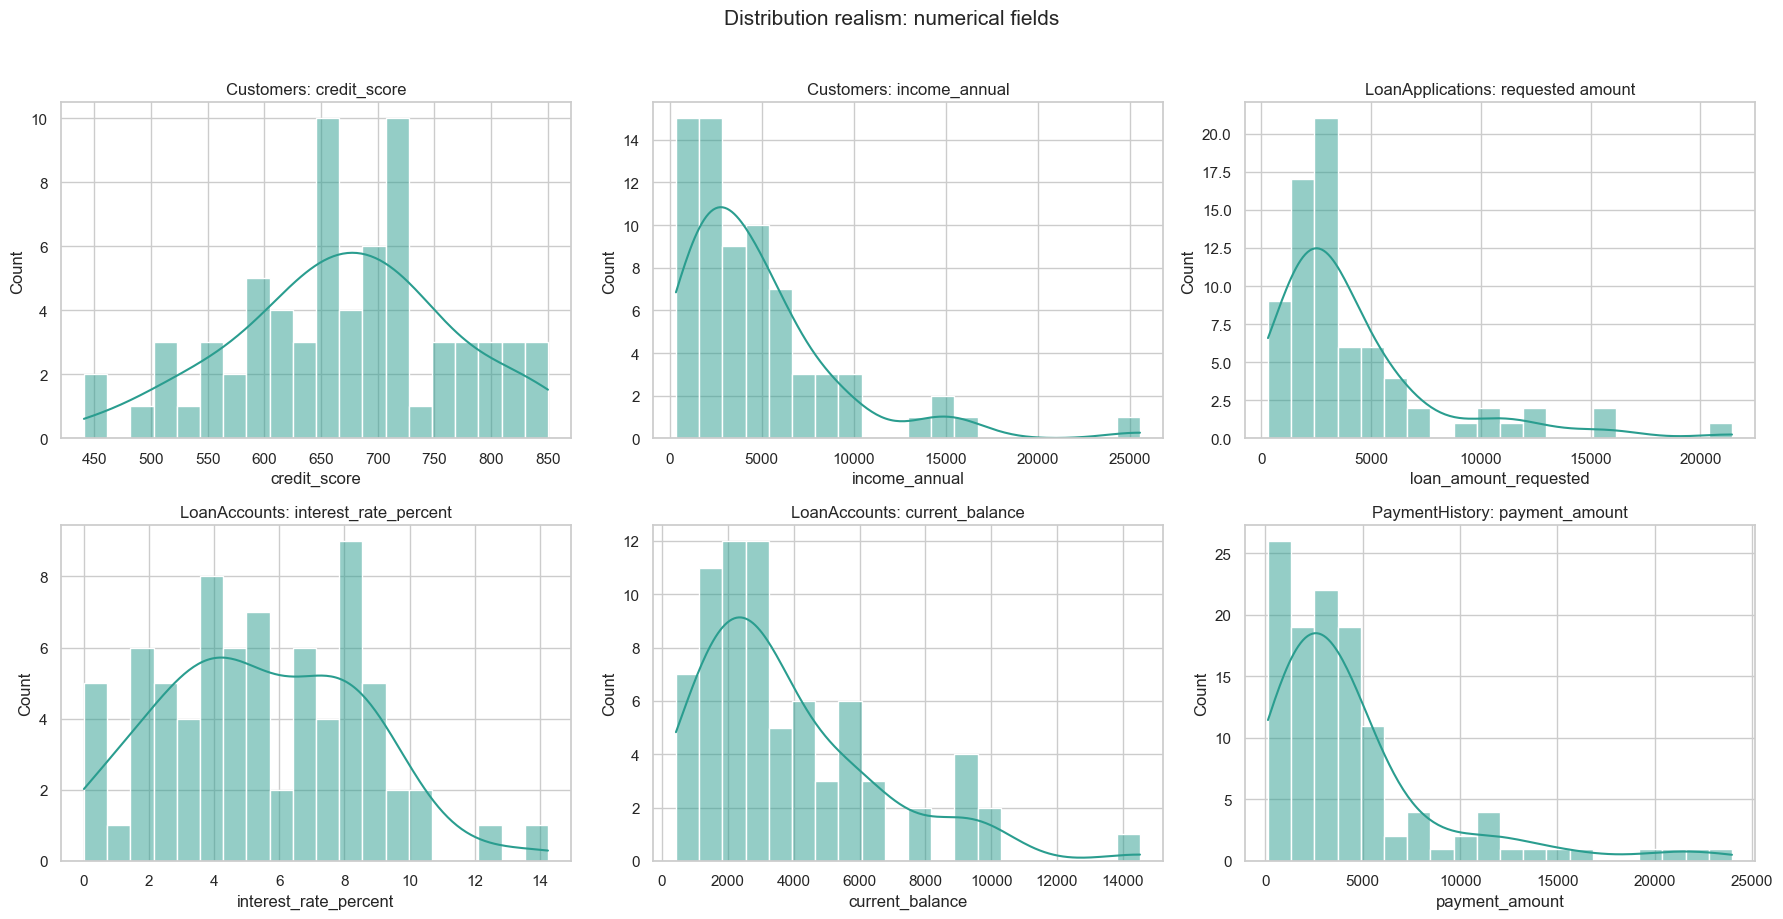

In [6]:
numeric_specs = [
    ("customers", "credit_score", "Customers: credit_score"),
    ("customers", "income_annual", "Customers: income_annual"),
    ("loanapplications", "loan_amount_requested", "LoanApplications: requested amount"),
    ("loanaccounts", "interest_rate_percent", "LoanAccounts: interest_rate_percent"),
    ("loanaccounts", "current_balance", "LoanAccounts: current_balance"),
    ("paymenthistory", "payment_amount", "PaymentHistory: payment_amount"),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 9))

for ax, (table_name, column, title) in zip(axes.flatten(), numeric_specs):
    series = pd.to_numeric(tables[table_name][column], errors="coerce").dropna()
    sns.histplot(series, kde=True, bins=20, ax=ax, color="#2a9d8f")
    ax.set_title(title)
    ax.set_xlabel(column)

plt.suptitle("Distribution realism: numerical fields", y=1.02, fontsize=15)
plt.tight_layout()
plt.show()

# 4) Distribution realism: categorical columns

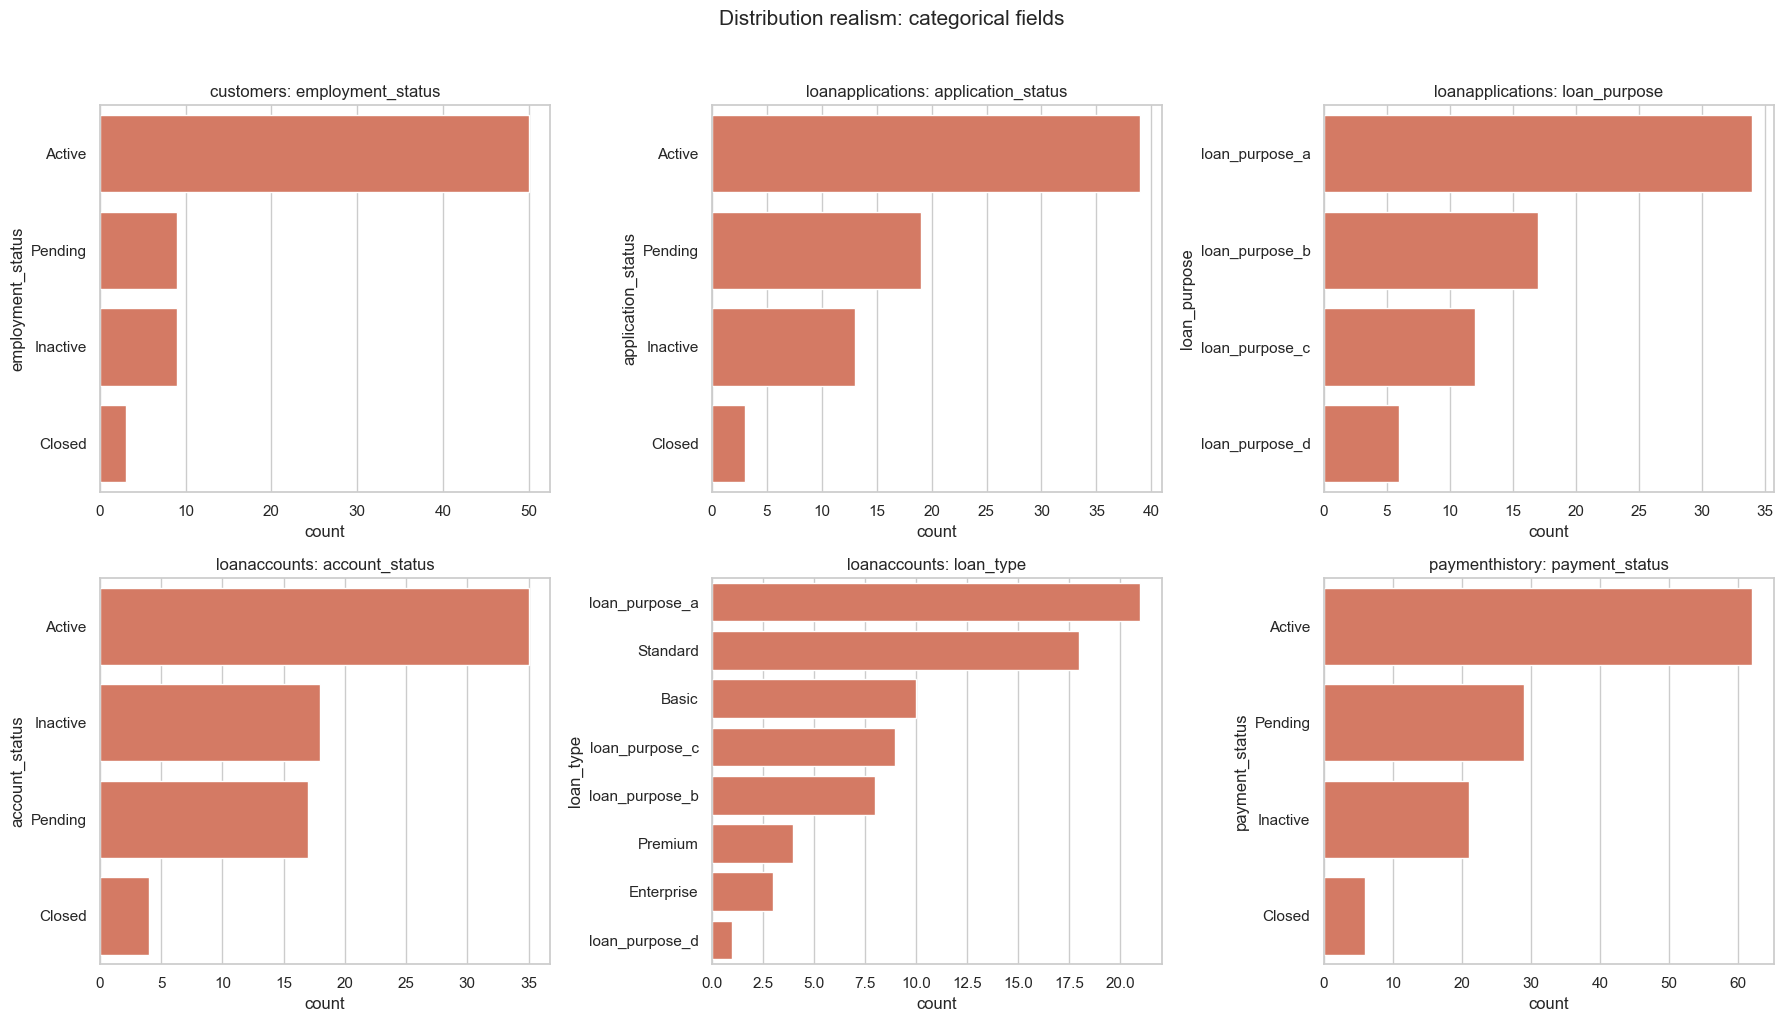

In [7]:
categorical_specs = [
    ("customers", "employment_status", 8),
    ("loanapplications", "application_status", 8),
    ("loanapplications", "loan_purpose", 8),
    ("loanaccounts", "account_status", 8),
    ("loanaccounts", "loan_type", 8),
    ("paymenthistory", "payment_status", 8),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, (table_name, column, top_n) in zip(axes.flatten(), categorical_specs):
    counts = (
        tables[table_name][column].astype("string").dropna().value_counts().head(top_n)
    )
    sns.barplot(x=counts.values, y=counts.index, ax=ax, color="#e76f51")
    ax.set_title(f"{table_name}: {column}")
    ax.set_xlabel("count")
    ax.set_ylabel(column)

plt.suptitle("Distribution realism: categorical fields", y=1.02, fontsize=15)
plt.tight_layout()
plt.show()

# 5) FK integrity checks (relationship preservation)

FK integrity summary


,relationship,child_rows,valid_rows,invalid_rows,valid_rate
0,LoanApplications.customer_id -> Customers.cust...,74,74,0,1.0
1,LoanAccounts.application_id -> LoanApplication...,74,74,0,1.0
2,LoanAccounts.customer_id -> Customers.customer_id,74,74,0,1.0
3,PaymentHistory.loan_account_id -> LoanAccounts...,118,118,0,1.0


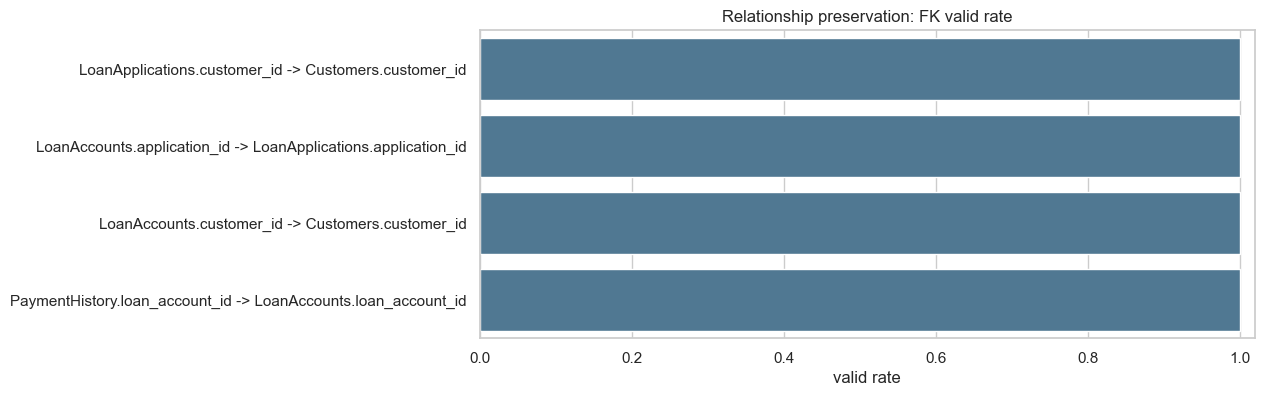

In [8]:
fk_checks = [
    (
        "LoanApplications.customer_id -> Customers.customer_id",
        loanapplications,
        "customer_id",
        customers,
        "customer_id",
    ),
    (
        "LoanAccounts.application_id -> LoanApplications.application_id",
        loanaccounts,
        "application_id",
        loanapplications,
        "application_id",
    ),
    (
        "LoanAccounts.customer_id -> Customers.customer_id",
        loanaccounts,
        "customer_id",
        customers,
        "customer_id",
    ),
    (
        "PaymentHistory.loan_account_id -> LoanAccounts.loan_account_id",
        paymenthistory,
        "loan_account_id",
        loanaccounts,
        "loan_account_id",
    ),
]

fk_rows: list[dict[str, object]] = []
for label, child_df, child_key, parent_df, parent_key in fk_checks:
    child_values = child_df[child_key].dropna()
    parent_values = set(parent_df[parent_key].dropna())
    valid = child_values.isin(parent_values)
    fk_rows.append(
        {
            "relationship": label,
            "child_rows": int(len(child_values)),
            "valid_rows": int(valid.sum()),
            "invalid_rows": int((~valid).sum()),
            "valid_rate": float(valid.mean()) if len(valid) else 1.0,
        }
    )

fk_df = pd.DataFrame(fk_rows).sort_values("valid_rate", ascending=True)
print("FK integrity summary")
display(fk_df)

plt.figure(figsize=(10, 4))
sns.barplot(data=fk_df, y="relationship", x="valid_rate", color="#457b9d")
plt.xlim(0, 1.02)
plt.title("Relationship preservation: FK valid rate")
plt.xlabel("valid rate")
plt.ylabel("")
plt.show()

# 6) Parent-child cardinality patterns (relationship preservation)


Parent-child cardinality summary


,metric,mean,median,p95,max
0,Applications per customer,1.541667,1.0,3.0,6
1,Loan accounts per customer,1.608696,1.0,3.0,8
2,Payments per loan account,2.145455,2.0,5.6,10


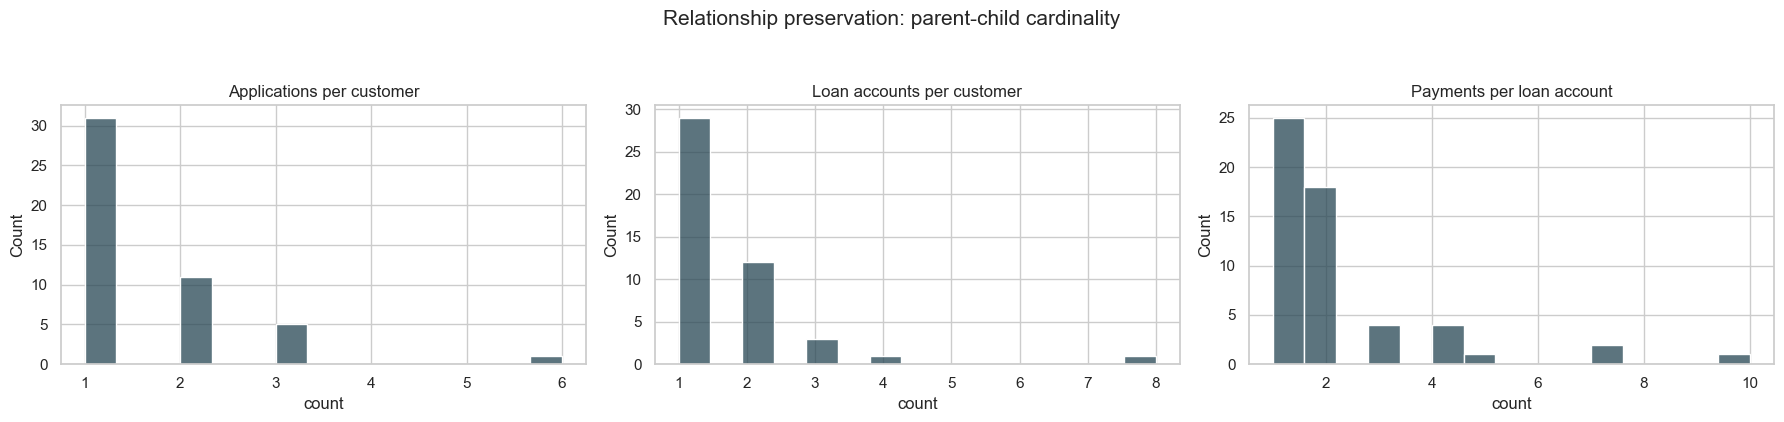

In [9]:
apps_per_customer = loanapplications.groupby("customer_id").size()
accounts_per_customer = loanaccounts.groupby("customer_id").size()
payments_per_account = paymenthistory.groupby("loan_account_id").size()

cardinality = {
    "Applications per customer": apps_per_customer,
    "Loan accounts per customer": accounts_per_customer,
    "Payments per loan account": payments_per_account,
}

cardinality_stats = pd.DataFrame(
    [
        {
            "metric": name,
            "mean": float(series.mean()),
            "median": float(series.median()),
            "p95": float(series.quantile(0.95)),
            "max": int(series.max()),
        }
        for name, series in cardinality.items()
    ]
)

print("Parent-child cardinality summary")
display(cardinality_stats)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, (name, series) in zip(axes, cardinality.items()):
    sns.histplot(series, bins=15, ax=ax, color="#264653")
    ax.set_title(name)
    ax.set_xlabel("count")

plt.suptitle("Relationship preservation: parent-child cardinality", y=1.05, fontsize=15)
plt.tight_layout()
plt.show()

# 7) Relationship consistency examples

Consistency check: payment_type vs loan_type


,metric,value
0,payment_type matches parent loan_type,0.966102


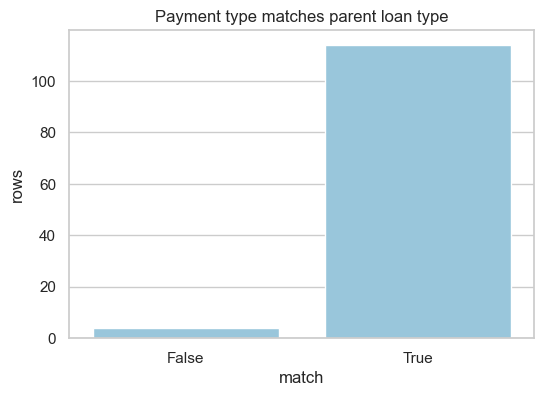

Consistency check: payment_status conditioned on account_status


payment_status,Active,Closed,Inactive,Pending
account_status,,,,
Active,0.816667,0.00,0.083333,0.100000
Closed,0.000000,1.00,0.000000,0.000000
Inactive,0.150000,0.25,0.600000,0.000000
Pending,0.270270,0.00,0.108108,0.621622


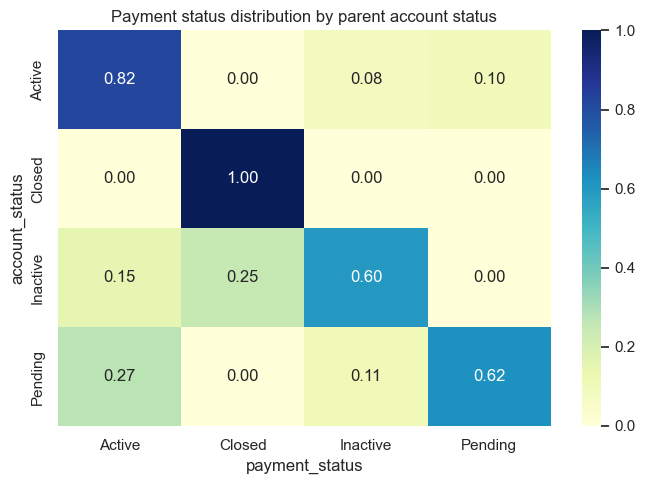

Consistency check: temporal order


,metric,value,rows_checked
0,payment_date >= origination_date,1.0,36


In [10]:
payment_join = paymenthistory.merge(
    loanaccounts[
        ["loan_account_id", "loan_type", "account_status", "origination_date"]
    ],
    on="loan_account_id",
    how="left",
)

# Example A: payment_type vs parent loan_type
payment_join["payment_type_matches_loan_type"] = (
    payment_join["payment_type"] == payment_join["loan_type"]
)
type_match_rate = payment_join["payment_type_matches_loan_type"].mean()

type_match_df = pd.DataFrame(
    {
        "metric": ["payment_type matches parent loan_type"],
        "value": [float(type_match_rate)],
    }
)
print("Consistency check: payment_type vs loan_type")
display(type_match_df)

plt.figure(figsize=(6, 4))
sns.countplot(data=payment_join, x="payment_type_matches_loan_type", color="#8ecae6")
plt.title("Payment type matches parent loan type")
plt.xlabel("match")
plt.ylabel("rows")
plt.show()


# Example B: payment_status vs parent account_status
status_matrix = pd.crosstab(
    payment_join["account_status"],
    payment_join["payment_status"],
    normalize="index",
)

print("Consistency check: payment_status conditioned on account_status")
display(status_matrix)

plt.figure(figsize=(7, 5))
sns.heatmap(status_matrix, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Payment status distribution by parent account status")
plt.xlabel("payment_status")
plt.ylabel("account_status")
plt.tight_layout()
plt.show()


# Example C: temporal consistency (payment_date >= origination_date)
temporal_df = payment_join.dropna(subset=["payment_date", "origination_date"]).copy()
temporal_df["payment_after_origination"] = (
    temporal_df["payment_date"] >= temporal_df["origination_date"]
)

temporal_rate = temporal_df["payment_after_origination"].mean()
temporal_summary = pd.DataFrame(
    {
        "metric": ["payment_date >= origination_date"],
        "value": [float(temporal_rate)],
        "rows_checked": [len(temporal_df)],
    }
)
print("Consistency check: temporal order")
display(temporal_summary)

# 8) Use generator quality report directly (rubric-ready evidence)

From data_quality_report.json: fk_integrity


,relationship,rows,nulls,invalid,valid_rate
0,LoanApplications.customer_id,74.0,0.0,0.0,1.0
1,LoanAccounts.application_id,74.0,0.0,0.0,1.0
2,LoanAccounts.customer_id,74.0,0.0,0.0,1.0
3,PaymentHistory.loan_account_id,118.0,0.0,0.0,1.0


From data_quality_report.json: relationship_rule_summary


,rule,rows,nulls,aligned,alignment_rate
0,token_overlap_copy,354.0,9.0,345.0,1.0000
2,parent_risk_copy,70.0,5.0,65.0,1.0000
3,parent_type_copy,112.0,0.0,112.0,1.0000
1,status_transition,264.0,0.0,188.0,0.7121


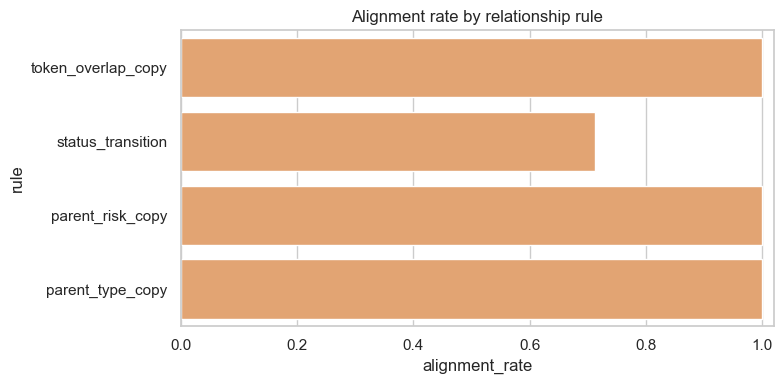

In [11]:
report_path = DATA_ROOT / "data_quality_report.json"
with report_path.open("r", encoding="utf-8") as f:
    report = json.load(f)

fk_report_df = (
    pd.DataFrame(report.get("fk_integrity", {}))
    .T.reset_index()
    .rename(columns={"index": "relationship"})
)

rule_df = (
    pd.DataFrame(report.get("relationship_rule_summary", {}))
    .T.reset_index()
    .rename(columns={"index": "rule"})
)

print("From data_quality_report.json: fk_integrity")
display(fk_report_df)

if not rule_df.empty:
    print("From data_quality_report.json: relationship_rule_summary")
    display(rule_df.sort_values("alignment_rate", ascending=False))

    plt.figure(figsize=(8, 4))
    sns.barplot(data=rule_df, x="alignment_rate", y="rule", color="#f4a261")
    plt.xlim(0, 1.02)
    plt.title("Alignment rate by relationship rule")
    plt.xlabel("alignment_rate")
    plt.ylabel("rule")
    plt.tight_layout()
    plt.show()


# 9) Rubric-ready one-table summary

In [12]:
min_fk_valid_rate = float(fk_df["valid_rate"].min()) if not fk_df.empty else 1.0
min_rule_alignment = (
    float(rule_df["alignment_rate"].min()) if not rule_df.empty else float("nan")
)

rubric_summary = pd.DataFrame(
    [
        {
            "rubric_focus": "Distribution realism",
            "evidence": "Numeric and categorical distributions plotted across all core tables.",
            "key_indicator": "See sections 3 and 4",
        },
        {
            "rubric_focus": "Preservation of relationships",
            "evidence": "FK checks, parent-child cardinality plots, and relationship alignment metrics.",
            "key_indicator": f"min FK valid_rate={min_fk_valid_rate:.3f}, min rule alignment={min_rule_alignment:.3f}",
        },
    ]
)

print("Rubric-ready summary")
display(rubric_summary)

Rubric-ready summary


,rubric_focus,evidence,key_indicator
0,Distribution realism,Numeric and categorical distributions plotted ...,See sections 3 and 4
1,Preservation of relationships,"FK checks, parent-child cardinality plots, and...","min FK valid_rate=1.000, min rule alignment=0.712"
